
<div style="text-align: center; font-weight: bold;">
    <h1>Getting Started: Setting up Workspace and Data Overview</h1>
    <h4>Author: Vidul Ayakulangara Panickan</h3>
</div>




**How the Tutorial is Structured**  

This tutorial is divided into three parts.  

- **Part 1: Data Cleaning**  
- **Part 2: Medical Code Rollup**  
- **Part 3: Natural Language Processing**  
- **Part 4: Cohort Creation**

In each part, we will walk through the key steps using MIMIC-IV datasets as examples and then define reusable functions that encompass these steps, allowing them to be applied to other MIMIC-IV datasets.

**Prerequisites:**  
1. Python programming basics and Pandas library
2. Access to Medical Information Mart for Intensive Care data ([MIMIC-IV 3.1](https://physionet.org/content/mimiciv/3.1/))
3. A [UMLS](https://www.nlm.nih.gov/research/umls/index.html) account


## Gaining Access to MIMIC-IV Dataset

MIMIC-IV is a deidentified EHR dataset sourced from BIDMC Hospital. To gain access to MIMIC-IV, follow these steps

1. You will need to be a credentialed user. You can register in [here](https://physionet.org/register/) to create a physionet account and become a credential user
2. Complete the training listed [here](https://physionet.org/content/mimiciv/view-required-training/3.1/) and submit the trainings [here](https://physionet.org/settings/training/)
3. Sign the Data User Agreement [here](https://physionet.org/login/?next=/sign-dua/mimiciv/3.1/)

Once your access is approved, you will receive a notification via your registered email.

## Setting up your Compute Environment


1. Create a workspace to download and process MIMIC-IV data.
2. Download all the tutorial notebooks into the workspace.
3. Create a virtual environment and install the required Python libraries.
4. Download the MIMIC data into the workspace.

For this tutorial, the file structure is organized as below. For Unix-based systems, we provide a setup script that will automatically create the necessary directories, prepares the environment and downloads the required datasets.

```plaintext
EHR_TUTORIAL_WORKSPACE/
├── processed_data/                # Outputs after cleaning & standardization
│
├── raw_data/                      # Original downloaded MIMIC data
│   ├── note_data/
│   │   └── physionet.org/
│   │       └── files/
│   │           └── mimic-iv-note/
│   │               └── 2.2/
│   │                   └── note/
│   │                       └── *.csv.gz
│   │
│   └── structured_data/
│       └── physionet.org/
│           └── files/
│               └── mimiciv/
│                   └── 3.1/
│                       ├── hosp/
│                       │   └── *.csv.gz
│                       └── icu/
│                           └── *.csv.gz
│
└── scripts/                       # Tutorial ipynb notebooks & mapping files
    └── EHR-Processing-Tutorial-main/
        ├── meta_files/  
        └── Rollup_Mappings/
            

```


The following script can be run on Unix based systems to setup the workspace. 

```bash
#!/bin/bash

# Set the location variable to the path where you want to create the MIMIC workspace
LOCATION="/path/to/your/workspace"

# If you would like to download and work in your home directory, you can update above to LOCATION="$HOME"

# Check if the workspace folder already exists
if [ -d "${LOCATION}/EHR_TUTORIAL_WORKSPACE" ]; then
  echo "EHR_TUTORIAL_WORKSPACE folder already exists here ${LOCATION}/EHR_TUTORIAL_WORKSPACE"
  exit 0
fi

# Create the workspace directory
mkdir "${LOCATION}/EHR_TUTORIAL_WORKSPACE"
echo "Workspace has been created here ${LOCATION}/EHR_TUTORIAL_WORKSPACE"

# Create the workspace subdirectories
echo "Creating raw_data, processed_data, and scripts subdirectories"
mkdir -p "${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/structured_data" \
         "${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/note_data" \
         "${LOCATION}/EHR_TUTORIAL_WORKSPACE/processed_data" \
         "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts"
echo "Workspace has been set up here ${LOCATION}/EHR_TUTORIAL_WORKSPACE"

# Download and extract MIMIC Data Prep scripts from GitHub
echo "Downloading and extracting MIMIC Data Prep scripts from GitHub..."
wget https://github.com/apvidul/EHR-Processing-Tutorial/archive/refs/heads/main.zip -O mimic-data-prep.zip
unzip -q mimic-data-prep.zip -d "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts"
mv "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts/EHR-Processing-Tutorial-main/"* "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts/"

# Cleanup unnecessary files and folders
rm -rf mimic-data-prep.zip "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts/EHR-Processing-Tutorial-main"

echo "Creating the Conda environment ehr_tutorial"
conda create --yes --name ehr_tutorial pandas wordcloud jupyter tqdm matplotlib

# Downloading the structured MIMIC data into raw_data/structured_data
wget -r -N -c -np --user ${PHYSIONET_USERNAME} --password ${PHYSIONET_PASSWORD} \
  https://physionet.org/files/mimiciv/3.1/ \
  -P ${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/structured_data

# Downloading the note data into raw_data/note_data
wget -r -N -c -np --user ${PHYSIONET_USERNAME} --password ${PHYSIONET_PASSWORD} \
  https://physionet.org/files/mimic-iv-note/2.2/ \
  -P ${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/note_data

```


Once MIMIC is downloaded, you are ready to work on this notebook. The data is currently in zipped format, you can go ahead and run the following block to unzip.

In [7]:
import os

# Specifice the tutorial workspace location below
LOCATION = "/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

# Build the path to the .gz files using os.path.join
hosp_gz_files_path = os.path.join(LOCATION, "raw_data","structured_data" ,"physionet.org", "files", "mimiciv", "3.1", "hosp")

# Run the gunzip command directly in the IPython notebook
print("Please wait, files are being unzipped")
!gunzip {hosp_gz_files_path}/*.gz
print(f"All .gz files in {hosp_gz_files_path} have been unzipped.\n")


note_gz_files_path = os.path.join(LOCATION, "raw_data", "note_data","physionet.org", "files", "mimic-iv-note", "2.2", "note")
!gunzip {note_gz_files_path}/*.gz

print(f"All .gz files in {note_gz_files_path} have been unzipped.\n")


Please wait, files are being unzipped
gzip: /n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE/raw_data/structured_data/physionet.org/files/mimiciv/3.1/hosp/*.gz: No such file or directory
All .gz files in /n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE/raw_data/structured_data/physionet.org/files/mimiciv/3.1/hosp have been unzipped.

gzip: /n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE/raw_data/note_data/physionet.org/files/mimic-iv-note/2.2/note/*.gz: No such file or directory
All .gz files in /n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE/raw_data/note_data/physionet.org/files/mimic-iv-note/2.2/note have been unzipped.



## EHR Data Overview

After gaining access, it is essential to develop a thorough understanding of the EHR data to assemble the elements of interest and create a dataset aligned with the research objectives. This typically involves answering the following questions:

1. **What data is available, and where is it stored?**
2. **Which data elements are relevant, and how are they defined?**
3. **How is the data organized and linked across files and tables?**

These questions are typically addressed by consulting institution specific EHR documentation or the warehouse data manager. For MIMIC-IV, comprehensive documentation is available on the project website [here](https://mimic.mit.edu/docs/iv/).

For users new to EHR data, we highly recommend watching the MIMIC data tutorial [here](https://mimic.mit.edu/docs/iv/tutorials/video/).


#### What data is available and where is it stored?
Electronic Health Record (EHR) data can take many forms. For example, billing information and vital signs are typically recorded as tabular data, clinical notes are typically in free text format, ECG recordings generate waveform data, and procedures such as X-rays or CT scans generate image data. These data originate from various systems within the hospital and contain a wealth of information. Today, several frameworks facilitate clinical research using EHR data such as the [i2b2](https://community.i2b2.org/wiki/display/BUN/2.+Quick+Start+Guide) framework from MGB and Harvard and [VINCI](https://www.research.va.gov/programs/vinci/), maintained by Veterans Affairs, which provide both data and analytical tools to support research and analysis.

EHR data is typically stored in databases. In this tutorial, we will be working with MIMIC data stored as flat files. MIMIC-IV data comes in “modules” based on the source of data generation. Following are the five modules currently made available:

- [hosp](https://mimic.mit.edu/docs/iv/modules/hosp/) - Hospital-level data for patients, including labs, microbiology, and electronic medication administration records.  
- [icu](https://mimic.mit.edu/docs/iv/modules/icu/) - ICU-level data, including event tables (e.g., chart events) identical in structure to MIMIC-III.  
- [ed](https://mimic.mit.edu/docs/iv/modules/ed/) - Data from the emergency department.  
- [cxr](https://mimic.mit.edu/docs/iv/modules/cxr/) - Lookup tables and metadata from MIMIC-CXR, enabling linkage to MIMIC-IV.  
- [note](https://physionet.org/content/mimic-iv-note/2.2/) - De-identified free-text clinical notes.  

Below is a brief summary of the date contained in these modules

| Data type            | Data contents                          | Available at | Major tables / files                                   | Primary timestamps            |
|----------------------|--------------------------------------------|--------------------------|----------------------------------------------------------|---------------------------------|
| Diagnoses            | ICD-9/10 diagnosis codes per admission     | MIMIC-IV (hosp)          | `diagnoses_icd`, `d_icd_diagnoses`                       | Admission window (`admittime`, `dischtime`) |
| Procedures           | ICD-9/10-PCS, CPT/HCPCS events             | MIMIC-IV (hosp)          | `procedures_icd`, `hcpcsevents`, `d_icd_procedures`, `d_hcpcs` | Admission window; event dates (if present) |
| Medications          | Orders & administrations                   | MIMIC-IV (hosp)          | `prescriptions`, `emar`, `emar_detail`                   | `starttime`, `stoptime`, `charttime`        |
| Laboratory results   | Results + units                            | MIMIC-IV (hosp)          | `labevents`, `d_labitems`                                | `charttime`                      |
| Microbiology         | Cultures, organisms, sensitivities         | MIMIC-IV (hosp)          | `microbiologyevents`                                     | `charttime` / event time         |
| ICU flowsheets       | Vitals, assessments, outputs               | MIMIC-IV (icu)           | `chartevents`, `outputevents`, `icustays`, `d_items`     | `charttime`                      |
| Clinical notes       | Discharge, radiology, etc. (text)          | MIMIC-IV-Note            | `note`                                                   | `charttime` (or note time)       |
| Chest X-ray images   | DICOM/JPG images + study/series metadata   | MIMIC-CXR                | Image files + metadata CSVs                              | Study time / acquisition time    |
| ECG waveforms        | 10-sec, 12-lead diagnostic ECG waveforms   | MIMIC-IV-ECG             | WFDB waveform files + metadata                           | Acquisition time                 |
| ED stays (optional)  | Triage, meds, vitals during ED encounter   | MIMIC-IV-ED              | `edstays`, `triage`, `vitalsign`                         | ED times (arrival, discharge, etc.) |

For our tutorial, we will be working with MIMIC-IV `hosp` and `note` modules.

#### Which data elements are relevant, and how are they defined?

There are certain key data elements that are foundational for most EHR analyses.



| Key data element   | Description                                             | Examples in MIMIC-IV                                                                                 |
|--------------------|---------------------------------------------------------|-------------------------------------------------------------------------------------------------------|
| Unique Patient ID  | Patient identifier used across all tables and encounters| `subject_id`                                                                                          |
| Event              | A clinical record that something happened/was recorded  | Diagnoses (`diagnoses_icd`); Meds (`prescriptions`); Labs (`labevents`); Procedures (`procedures_icd`, `hcpcsevents`) |
| Time               | When the event occurred or was recorded                 | Event times (`charttime`, `starttime`, `stoptime`); admission window (`admittime`, `dischtime`) from `admissions`      |


The hosp module consists of  all data acquired from the hospital wide electronic health record. This includes patient information, lab measurements, microbiology, medication administered, and billed diagnoses. More information on tables in this module can be read on MIMIC IV documentation [here](https://mimic.mit.edu/docs/iv/modules/hosp/). Depending on your research needs, multiple tables may be relevant. Below, we list the tables we will be using in this tutorial.

| Type           | Table                | Purpose / contents                                                    | Key element(s) provided                | Primary code fields              | Primary time field(s) or anchor             | Typical join keys                 | Notes                                   |
|-------------------|----------------------|------------------------------------------------------------------------|----------------------------------------|----------------------------------|---------------------------------------------|-----------------------------------|-----------------------------------------|
| Data Dictionary   | `d_hcpcs`            | CPT/HCPCS code definitions                                            | Codes                                  | `hcpcs_cd`                       | —                                           | Link to `hcpcsevents.hcpcs_cd`    |                                         |
| Data Dictionary   | `d_icd_diagnoses`    | ICD-9/10 diagnosis code definitions                                   | Codes                                  | `icd_code`, `icd_version`       | —                                           | Link to `diagnoses_icd`           |                                         |
| Data Dictionary   | `d_icd_procedures`   | ICD-9/10 procedure code definitions                                   | Codes                                  | `icd_code`, `icd_version`       | —                                           | Link to `procedures_icd`          |                                         |
| Data Dictionary   | `d_labitems`         | Lab item dictionary (labels, categories, units metadata)              | Codes                                  | `itemid`                         | —                                           | Link to `labevents.itemid`        |                                         |
| Event Table       | `diagnoses_icd`      | Billed ICD diagnosis codes per hospitalization                        | Patient ID · Event · Codes             | `icd_code`, `icd_version`       | **Admission window** (`admittime`→`dischtime`) | `subject_id`, `hadm_id`           | No event timestamp in table             |
| Event Table       | `prescriptions`      | Medication orders                                                      | Patient ID · Event · **Time**          | Local drug fields / `ndc` (opt.) | `starttime`, `stoptime`                      | `subject_id`, `hadm_id`           | Map to RxNorm downstream if needed      |
| Event Table       | `labevents`          | Laboratory measurements (values + units)                              | Patient ID · Event · **Time** · Codes  | `itemid`                         | `charttime`                                  | `subject_id`, `hadm_id` (often)   | Values in `valuenum`, units in `valueuom` |
| Event Table       | `hcpcsevents`        | CPT/HCPCS billed events during hospitalization                        | Patient ID · Event · **Time** · Codes  | `hcpcs_cd`                       | `chartdate`                                  | `subject_id`, `hadm_id`           | (Typo fix: table is **hcpcsevents**)     |
| Event Table       | `procedures_icd`     | ICD-9/10-PCS billed procedures                                        | Patient ID · Event · Codes             | `icd_code`, `icd_version`       | **Admission window** (`admittime`→`dischtime`) | `subject_id`, `hadm_id`           | No event timestamp in table             |
| Patient Metadata  | `admissions`         | Admission episodes (in/out times, service, outcomes)                  | Patient ID · **Time**                  | —                                | `admittime`, `dischtime` (± `deathtime`)     | `subject_id`, `hadm_id`           | Use as time anchor for Dx/Proc tables    |
| Patient Metadata  | `transfers`          | Unit/ward movements within the hospital                               | Patient ID · **Time**                  | —                                | `intime`, `outtime`                           | `subject_id`, `hadm_id`           | Useful for location-aware analyses       |
| Patient Metadata  | `patients`           | Demographics and anchor fields                                        | Patient ID                              | —                                | (Optional) date of death                      | `subject_id`                      | No codes; demographics only              |




#### How is the data organized and linked across files and tables?

In EHR data, information can be spread across multiple tables or datasets. You will need to link data from different tables to create comprehensive dataset depending on your research needs. One of the key aspects for linking data is identifiers. The following are three major identifiers are used in MIMIC data. 

- **`SUBJECT_ID`**: This is a patient level identifier. The patients tables contains demographics for each unique patient
- **`HADM_ID`**: This is a hospital level identifier provided in the hosp module. Each unique hospital admission for a patient gets a unique id.
- **`STAY_ID`**: All ICU admissions within 24 hours of each other are grouped and assigned an identifier.


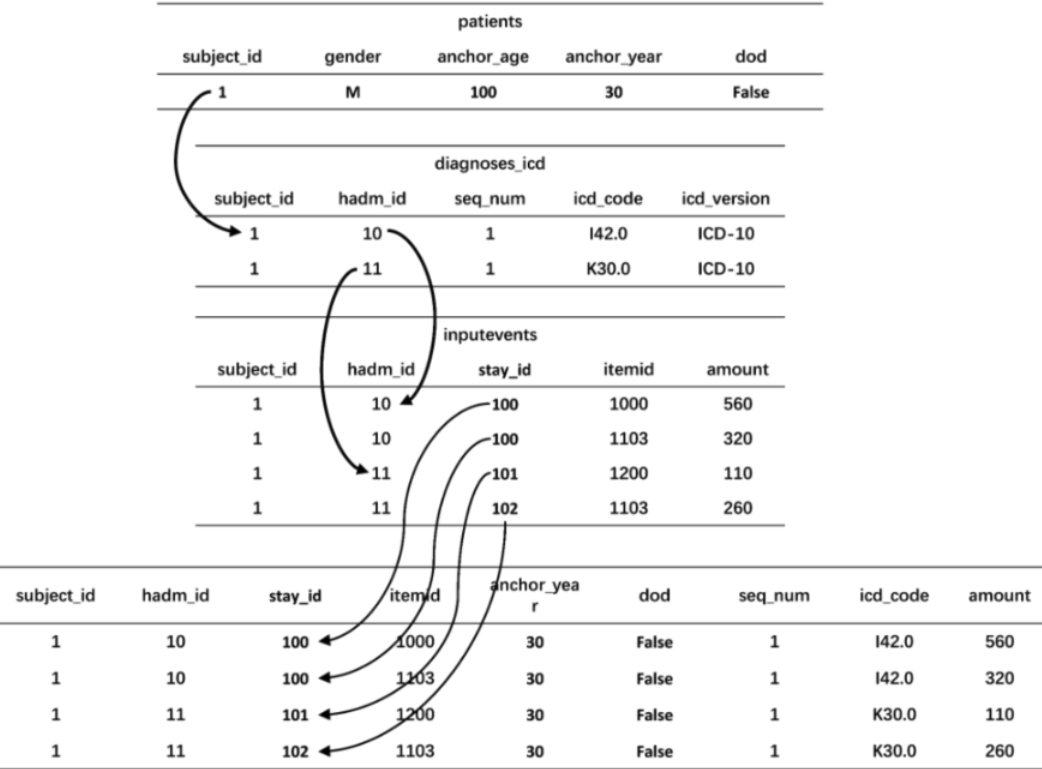

## MIMIC-IV Data Overview

In this step, we explore the individual tables withing the MIMIC-IV hosp module and summarize them. We will start with patient demographics data and then go over diagnoses, medications, labs, and procedures. One critical aspect of processing EHR data is ensuring that you account for every EHR code.

In [57]:
# Importing required libraries.

import pandas as pd
from collections import defaultdict
import heapq
from wordcloud import WordCloud
import matplotlib.pyplot as plt



base_directory ="/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

In [9]:
# We will create a directory to store summary data we will generate 

base_directory ="/n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE"

summary_directory = os.path.join(base_directory, 'processed_data', 'Summary')

print(f"Creating Summary directory here {summary_directory}")

os.makedirs(summary_directory, exist_ok=True)

Creating Summary directory here /n/data1/hsph/biostat/celehs/lab/va67/EHR_TUTORIAL_WORKSPACE/processed_data/Summary


In [10]:
# Summarizing Patient Demographics

demographics_file = os.path.join(base_directory, "raw_data", "structured_data","physionet.org", "files", "mimiciv", "3.1", "hosp","patients.csv")

demographics = pd.read_csv(demographics_file,dtype=str)

display(demographics.head())

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
count,364627,364627,364627,364627,364627,38301
unique,364627,2,73,99,5,22424
top,10000032,F,20,2165,2008 - 2010,2142-01-06
freq,1,191984,11031,4700,101607,7


Missing records in the Demographics table
subject_id                0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                  326326
dtype: int64


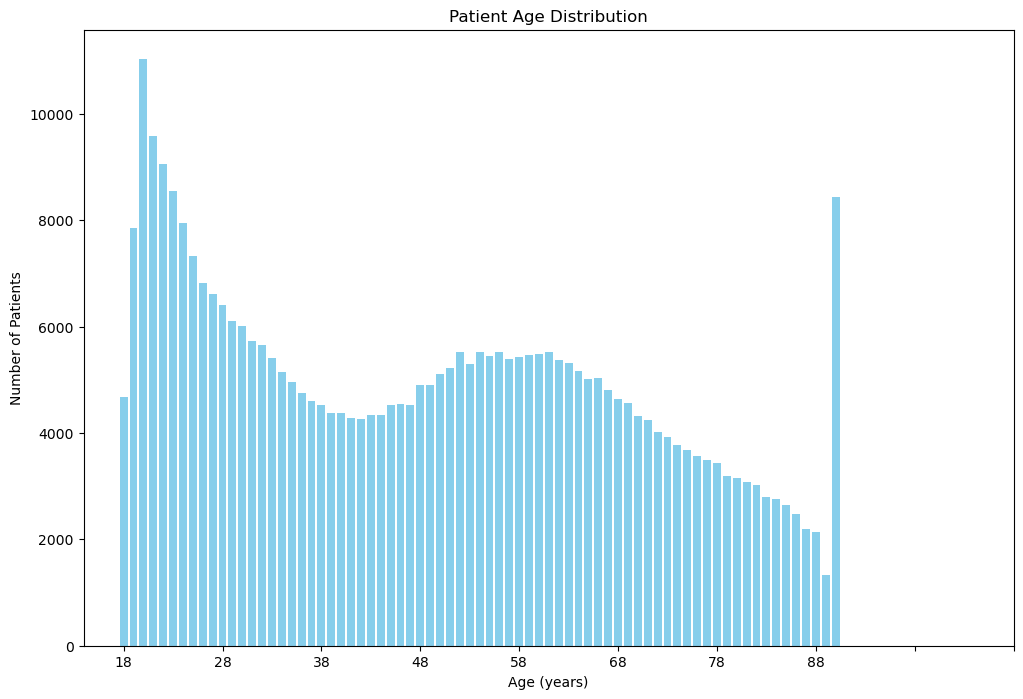

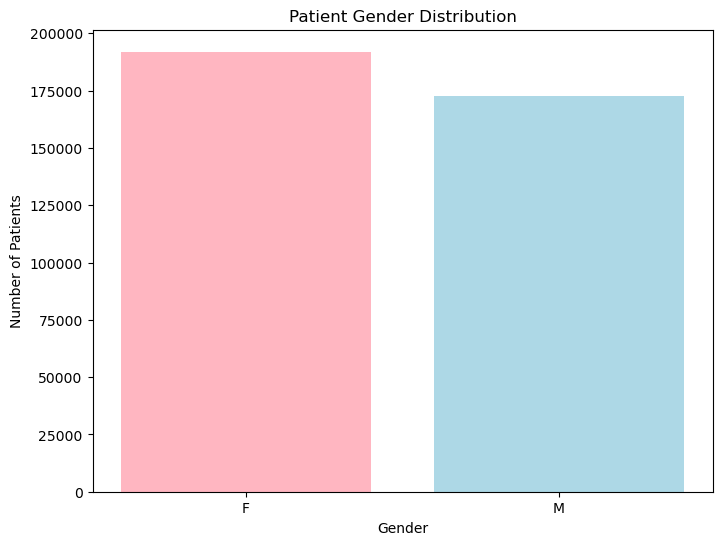

In [11]:
display(demographics.describe())

print("Missing records in the Demographics table")
print(demographics.isna().sum())

age_counts = demographics['anchor_age'].value_counts().sort_index()
plt.figure(figsize=[12, 8])
plt.bar(age_counts.index, age_counts.values, color='skyblue')
plt.xticks(range(0, 100, 10))
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.title('Patient Age Distribution')
plt.show()

gender_counts = demographics['gender'].value_counts()

# Create the bar chart with different colors directly in plt.bar()
plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=[{'F': 'lightpink', 'M': 'lightblue'}[g] for g in gender_counts.index])
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Patient Gender Distribution')
plt.show()

There are a total of `364,627` patients in the MIMIC-IV hospital dataset. Around `52%` of the patient cohort are female. We observe that there is no age data for patients with age < 18, and there is a huge spike at age 91 This is because ages over 89 are depicted as 90+ or as a median value above 90 to comply with HIPAA privacy regulations. The age and gender demographics can vary depending on the healthcare institution. For example, at a Veterans hospital, you typically see a larger male population and a higher average age, while at a Children's hospital, the patient population is much younger.

### Summarizing the Hosp Module 

#### Diagnoses Data

In U.S. healthcare systems, diagnoses are primarily documented using **ICD (International Classification of Diseases)** codes.

There are two versions of ICD codes in use:  
- **ICD-9**: used until **October 1, 2015**  
- **ICD-10**: starting **October 1, 2015**

It's important to note that the same diagnosis will be represented using different codes, depending on whether it was recorded before or after the transition in 2015. For a detailed comparison between ICD-9 and ICD-10 codes, you can read more [here](https://www.ama-assn.org/media/7546/download).

In [15]:
# Loading the tables as string format makes the data consistent throughout. 
diagnoses_icd_file = os.path.join(base_directory, "raw_data", "structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp","diagnoses_icd.csv")

diagnoses_icd = pd.read_csv(diagnoses_icd_file,dtype=str)

# We begin by examining first few rows of the data to get a sense of its structure
display(diagnoses_icd.head())

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [16]:
# We summarize the data

diagnoses_icd.describe()

,subject_id,hadm_id,seq_num,icd_code,icd_version
count,6364488,6364488,6364488,6364488,6364488
unique,223291,545497,39,28562,2
top,12468016,27635276,1,4019,10
freq,2396,57,545507,102368,3455747


From above, we can see that there are **`223,291`** patients in the `diagnoses_icd` table, which is **`68%`** of the total patients we saw in the patients table. The data descrepency we are seeing is because out of the 364,627 unique patients, only 223,452 had atleast one hospitalization and the remaining patients were seen only in the emergency department. This can be confirmed using the admissions table. This tutorial will be based on the the hospitalized patients.

It is crucial to identify and account for every medical code in the EHR data, as overlooking them can result in missing data, potentially compromising the results of your analysis. 

In the example above, we load the entire dataset at once because the diagnosis dataset is relatively small. 
However, for larger datasets, such as laboratory data or ECG, alternative methods are needed to handle the data efficiently. Below, we define a custom summarization function designed to process larger datasets. This function reads the data in batches, 
summarizes it, and provides the frequency distribution of individual EHR elements.

In [26]:
def get_basic_summary(filepath, batch_size):
    
    frequencies = defaultdict(lambda: defaultdict(int))
    non_null_records_count = defaultdict(int)
    total_records_count = 0

    for batch in pd.read_csv(filepath, chunksize=batch_size, dtype=str):
        total_records_count += len(batch)

        for column in batch.columns:
            non_null_records_count[column] += batch[column].notnull().sum()
    
            value_counts = batch[column].value_counts()
            for value, count in value_counts.items():
                frequencies[column][value] += count
                
    freq_table = [
        (column, len(frequencies[column]), non_null_records_count[column])
        for column in frequencies
    ]

    summary = pd.DataFrame(freq_table, columns=["Column_Name", "Unique_Values", "Non_Null_Records"])
    
    return {'summary':summary,'column_freq':frequencies,'records':total_records_count}

In [27]:
# Summarizing the data using the function defined above. 
batch_size = 5000000

summarize_output= get_basic_summary(diagnoses_icd_file, batch_size)

print("Total number of records in diagnoses icd file :", summarize_output['records'])

# Saving the summary to Summary folder
summarize_output['summary'].to_csv(os.path.join(summary_directory,"diagnoses_basic_summary.csv"),index=None)

summarize_output['summary']

Total number of records in diagnoses icd file : 6364488


,Column_Name,Unique_Values,Non_Null_Records
0,subject_id,223291,6364488
1,hadm_id,545497,6364488
2,seq_num,39,6364488
3,icd_code,28562,6364488
4,icd_version,2,6364488


Since we are now processing in batches, we can reuse the above function to handle larger datasets

In [28]:
# Next we'll count how freqeunt each column item appears in the diagnoses_icd and sort them by frequency 

column_frequencies = summarize_output["column_freq"]

for col, freq_data in column_frequencies.items():
    top_frequencies = heapq.nlargest(5, freq_data.items(), key=lambda x: x[1])
    freq_df = pd.DataFrame(top_frequencies, columns=[col, f"{col}_count"])
    display(freq_df)

,subject_id,subject_id_count
0,12468016,2396
1,18284271,2077
2,10577647,1850
3,15114531,1840
4,11582633,1777


,hadm_id,hadm_id_count
0,27635276,57
1,23076003,50
2,24773199,42
3,23416936,39
4,25781318,39


,seq_num,seq_num_count
0,1,545507
1,2,531552
2,3,508643
3,4,482201
4,5,452724


,icd_code,icd_code_count
0,4019,102368
1,E785,84570
2,I10,83775
3,2724,67293
4,Z87891,62806


,icd_version,icd_version_count
0,10,3455747
1,9,2908741


From the summary above, the most frequent ICD code is 4019, which corresponds to Unspecified essential hypertension. We also observe that ICD-10 codes appear more often than ICD-9 codes in this dataset.
To determine how many patients received a given diagnosis, count unique (subject_id, icd_code) pairs. This patient level count is essential for estimating disease cohort size

In [30]:
# Unique patient count per ICD code (by version), sorted by frequency
icd_counts = (
    diagnoses_icd
    .groupby(['icd_code', 'icd_version'], as_index=False)['subject_id']
    .nunique()
    .rename(columns={'subject_id': 'patient_count'})
    .sort_values('patient_count', ascending=False)
)

display(icd_counts.head())

,icd_code,icd_version,patient_count
2801,4019,9,52360
12953,I10,10,48611
10049,E785,10,45431
1342,2724,9,35210
28363,Z87891,10,32523


Now we know that MIMIC-IV hosp module have around 50k patients with the ICD code 4019 and 48k patients with the ICD code I10 and so on, among others.   

However, we do not know what these ICD codes correspond to. Typically, EHR datasets come with data dictionaries that provide EHR codes and their definitions. For MIMIC-IV, the ICD codes defenitions are provided in the `d_icd_diagnoses` table.

In [39]:
# Load icd code dictionary and and join to get the frequency count
d_icd_path = os.path.join(base_directory, "raw_data","structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp", "d_icd_diagnoses.csv")

sorted_icdcode_frequencies_w_def = (
    icd_counts  
    .merge(
        pd.read_csv(d_icd_path, dtype=str, usecols=["icd_code","icd_version","long_title"]),
        on=["icd_code","icd_version"], how="left"
    )
    .loc[:, ["icd_code","icd_version","long_title","patient_count"]]
    .sort_values("patient_count", ascending=False)
)

sorted_icdcode_frequencies_w_def.to_csv(os.path.join(summary_directory, "diagnoses_patient_count.csv"), index=False)
display(sorted_icdcode_frequencies_w_def.head())

,icd_code,icd_version,long_title,patient_count
0,4019,9,Unspecified essential hypertension,52360
1,I10,10,Essential (primary) hypertension,48611
2,E785,10,"Hyperlipidemia, unspecified",45431
3,2724,9,Other and unspecified hyperlipidemia,35210
4,Z87891,10,Personal history of nicotine dependence,32523


### <span style="color: #d9534f;">Important Note</span>

If you observe the top two most frequent code, you will see, both of the corresponds to hypertension. In the U.S., encounters before Oct 1, 2015 were coded in ICD9 CM, and encounters after Oct 1, 2015 got coded in ICD10 CM. For example, essential hypertension is 401.9 (stored as 4019 in MIMIC) under ICD9 CM and I10 under ICD10 CM. If your study spans this transition period, include both code sets

Let's go ahead and plot a wordcloud of ICD Code defnitions based on the frequency they appear in MIMIC-IV Diagnoses data

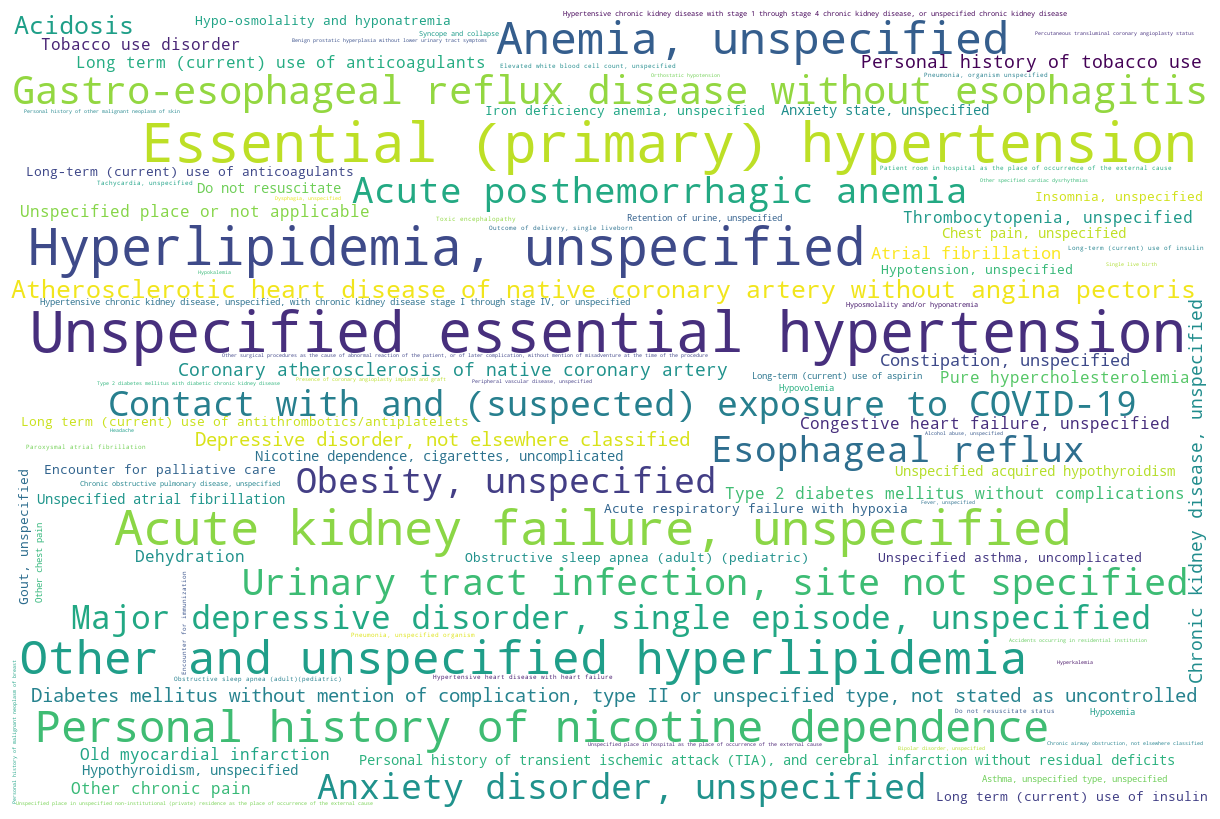

In [40]:
# Create a dictionary for the word cloud
word_freq = {}
for index, row in sorted_icdcode_frequencies_w_def.iterrows():
    title = row['long_title']
    count = row['patient_count']
    word_freq[title] = word_freq.get(title, 0) + count

# Customize the WordCloud
wordcloud = WordCloud(
    width=1200,           # Higher resolution
    height=800,
    background_color='white',  # Professional clean background
    colormap='viridis',   # Professional color palette
    prefer_horizontal=0.9,  # Mostly horizontal layout
    max_words=100,        # Limit number of displayed titles
    contour_width=1,      # Add a border
    contour_color='black', # Border color
    font_path=None        # You can use a professional font (optional)
).generate_from_frequencies(word_freq)

# Display the WordCloud using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.tight_layout(pad=0)
plt.show()


### Defining Functions

We will now define functions for the operations we performed earlier for processing diagnoses data and reuse them on all the datasets

In [64]:
import os
import heapq
from collections import defaultdict

import pandas as pd
from tqdm import tqdm
from wordcloud import WordCloud
import matplotlib.pyplot as plt

from IPython.display import display

# Set pandas options to expand all data within rows
pd.set_option('display.max_columns', None)      
pd.set_option('display.max_colwidth', None) 


def generate_wordcloud(sorted_icdcode_frequencies_w_def, code_desc_column):
    word_freq = {}
    for index, row in sorted_icdcode_frequencies_w_def.iterrows():
        title = row[code_desc_column]
        count = row['counts']
        word_freq[title] = word_freq.get(title, 0) + count
    
    # Customize the WordCloud
    wordcloud = WordCloud(
        width=1200,           # Higher resolution
        height=800,
        background_color='white',  # Professional clean background
        colormap='viridis',   # Professional color palette
        prefer_horizontal=0.9,  # Mostly horizontal layout
        max_words=100,        # Limit number of displayed titles
        contour_width=1,      # Add a border
        contour_color='black', # Border color
        font_path=None        # You can use a professional font (optional)
    ).generate_from_frequencies(word_freq)
    
    # Display the WordCloud using matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Hide axes
    plt.tight_layout(pad=0)
    plt.show()
    return wordcloud



def file_line_count(filepath):
    count = 0
    with open(filepath, 'r') as file:
        for line in file:
            count += 1
    return count



def get_basic_summary(filepath, cols_to_summarize, batch_size):
    
    frequencies = defaultdict(lambda: defaultdict(int))
    non_null_records_count = defaultdict(int)
    total_records_count = 0

    for batch in pd.read_csv(filepath, usecols=cols_to_summarize, chunksize=batch_size, dtype=str):
        total_records_count += len(batch)

        for column in batch.columns:
            # Update non-null record counts using vectorized operation
            non_null_records_count[column] += batch[column].notnull().sum()
    
            # Update frequencies using value_counts (vectorized frequency calculation)
            value_counts = batch[column].value_counts()
            for value, count in value_counts.items():
                frequencies[column][value] += count



    freq_table = [
        (column, len(frequencies[column]), non_null_records_count[column])
        for column in frequencies
    ]


    summary = pd.DataFrame(freq_table, columns=["Column_Name", "Unique_Values", "Non_Null_Records"])
    
    return {'summary':summary,'column_freq':frequencies,'records':total_records_count}

    
def generate_complete_summary(filepath,code_dictionary, patient_id_col, code_cols, cols_to_summarize, code_desc_column, summary_directory, batch_size):
    """
    Generate a comprehensive summary of an EHR dataset, including basic statistics,
    column value frequencies, and patient-code pair counts.
    
    """
    
    # Extract the base filename without extension
    filename = os.path.splitext(os.path.basename(filepath))[0]
    
    # Reusing the get_basic_summary function we defined before but optimized for batch processing
    summarize_output = get_basic_summary(filepath, cols_to_summarize, batch_size)
    total_rows = summarize_output['records']
    print(f"Total Rows in file: {total_rows}")
    
    total_chunks = (total_rows // batch_size) + (1 if total_rows % batch_size > 0 else 0)
    
    # Save the basic summary to a csv file
    summary_filepath = os.path.join(summary_directory, f"{filename}_basic_summary.csv")
    summarize_output['summary'].to_csv(summary_filepath, index=False)
    
    # Display top frequencies for each column
    column_frequencies = summarize_output["column_freq"]
    column_frequencies_dfs = []
    for col, freq_data in column_frequencies.items():
        top_frequencies = heapq.nlargest(5, freq_data.items(), key=lambda x: x[1])
        freq_df = pd.DataFrame(top_frequencies, columns=[col, f"{col}_count"])
        column_frequencies_dfs.append(freq_df)
        
    column_frequencies_df = pd.concat(column_frequencies_dfs,axis=1)
    print("Most frequent values under each column:")
    display(column_frequencies_df)
    most_freq_filepath = os.path.join(summary_directory, f"{filename}_most_freq_items.csv")
    column_frequencies_df.to_csv(most_freq_filepath, index=False)
    
    # Determine columns for patient-code pairs processing
    code_columns = [code_cols['code']]
    if 'code_version' in code_cols and code_cols['code_version']:
        code_columns.append(code_cols['code_version'])
    
    columns_to_read = [patient_id_col] + code_columns
    
    # Initialize list to store unique patient-code pairs across chunks
    subject_code_pairs_dfs = []
    
    # Read the dataset in chunks to process patient-code pairs
    chunk_iter = pd.read_csv(filepath, chunksize=batch_size, usecols=columns_to_read, dtype=str)
    for chunk_idx, chunk in enumerate(tqdm(chunk_iter, total=total_chunks, desc="Processing chunks")):
        # Drop duplicates within the current chunk
        unique_pairs = chunk[columns_to_read].drop_duplicates()
        subject_code_pairs_dfs.append(unique_pairs)
    
    # Combine unique pairs from all chunks and remove duplicates
    subject_code_pairs_full = pd.concat(subject_code_pairs_dfs, ignore_index=True).drop_duplicates()
    
    # Count occurrences of each unique code pair and sort by count in descending order
    sorted_code_pairs_counts = (
        subject_code_pairs_full[code_columns]
        .value_counts()
        .reset_index(name='counts')
    )

    sorted_code_freq_and_def = pd.merge(sorted_code_pairs_counts, code_dictionary, on=code_columns, how='left')

    print("Most frequent codes and their corresponding patient counts")
    
    display(sorted_code_freq_and_def.head())
    
    sorted_code_freq_and_def.to_csv(os.path.join(summary_directory,f"{filename}_basic_summary.csv"),index=None)
    
    wordcloud = generate_wordcloud(sorted_code_freq_and_def, code_desc_column)

    wordcloud_filepath = os.path.join(summary_directory, f"{filename}_wordcloud.png")
    
    wordcloud.to_file(wordcloud_filepath)

We will be processing four types of data: `Diagnoses`, `Procedures`, `Medications`, and `Labs`.

Total Rows in file: 6364488
Most frequent values under each column:


,subject_id,subject_id_count,icd_code,icd_code_count,icd_version,icd_version_count
0,12468016,2396,4019,102368,10,3455747.0
1,18284271,2077,E785,84570,9,2908741.0
2,10577647,1850,I10,83775,NaN,NaN
3,15114531,1840,2724,67293,NaN,NaN
4,11582633,1777,Z87891,62806,NaN,NaN


Processing chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.44s/it]


Most frequent codes and their corresponding patient counts


,icd_code,icd_version,counts,long_title
0,4019,9,52360,Unspecified essential hypertension
1,I10,10,48611,Essential (primary) hypertension
2,E785,10,45431,"Hyperlipidemia, unspecified"
3,2724,9,35210,Other and unspecified hyperlipidemia
4,Z87891,10,32523,Personal history of nicotine dependence


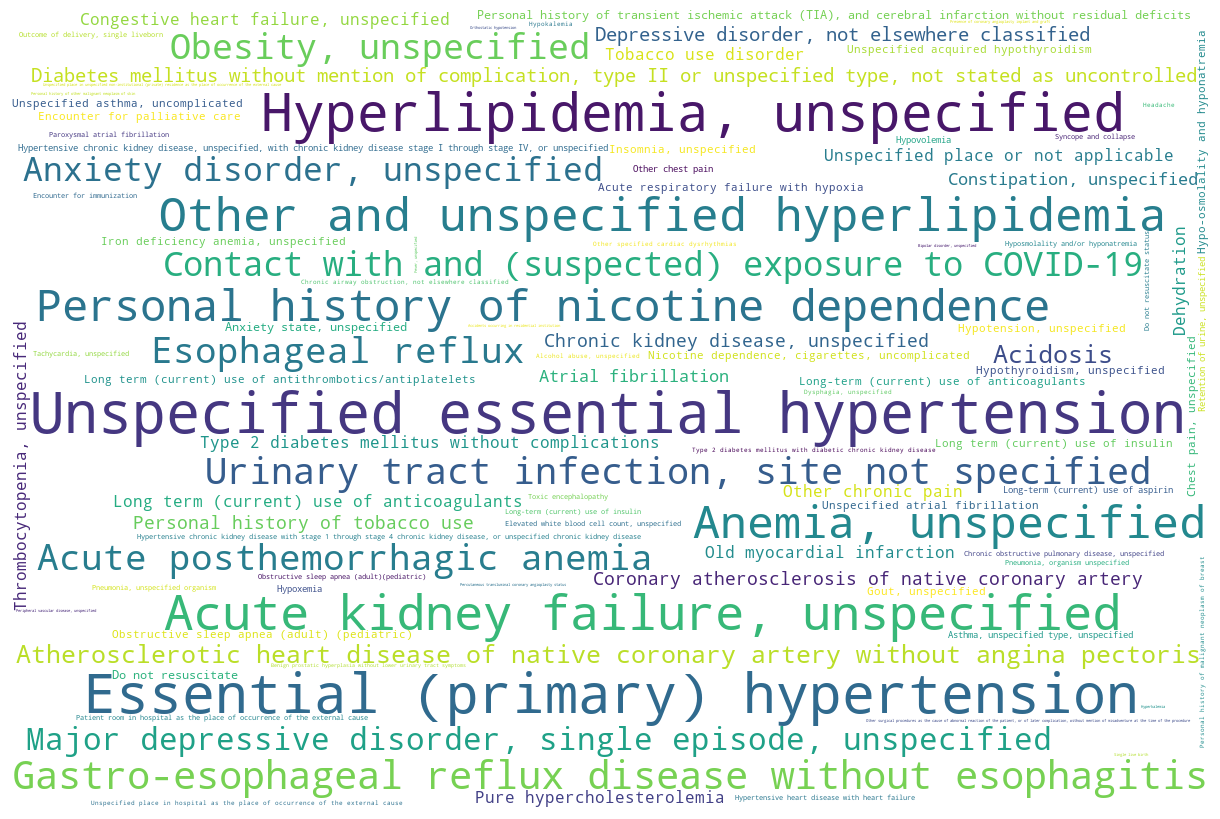

In [52]:
# Most frequent Diagnoses in MIMIC-IV Hosp module

diagnoses_icd_file = os.path.join(base_directory, "raw_data", "structured_data","physionet.org", "files", "mimiciv", "3.1", "hosp","diagnoses_icd.csv")
summary_directory = os.path.join(base_directory, 'processed_data', 'Summary')
d_icd_diagnoses_file = os.path.join(base_directory, "raw_data", "structured_data","physionet.org", "files", "mimiciv", "3.1", "hosp","d_icd_diagnoses.csv")
data_dictionary_icd = pd.read_csv(d_icd_diagnoses_file,dtype=str)

generate_complete_summary(
    diagnoses_icd_file, 
    data_dictionary_icd,
    patient_id_col = "subject_id",
    code_cols= {"code": "icd_code", "code_version":"icd_version"},
    cols_to_summarize=["subject_id","icd_code","icd_version"],
    code_desc_column ="long_title",
    summary_directory=summary_directory,
    batch_size=5000000
)

Total Rows in file: 186074
Most frequent values under each column:


,subject_id,subject_id_count,chartdate,chartdate_count,hcpcs_cd,hcpcs_cd_count
0,15496609,227,2179-03-13,32,G0378,68571
1,15464144,185,2183-11-19,28,99219,52408
2,10714009,150,2173-11-02,28,99218,12091
3,15229574,127,2177-08-16,28,99220,11069
4,14394983,125,2179-07-07,27,44970,1174


Processing chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.80it/s]

Most frequent codes and their corresponding patient counts


,hcpcs_cd,counts,category,long_description,short_description
0,G0378,39829,NaN,"Hospital observation service, per hour",Hospital observation per hr
1,99219,39387,1,NaN,Hospital observation services
2,99218,10458,1,NaN,Hospital observation services
3,99220,8354,1,NaN,Hospital observation services
4,44970,1174,1,NaN,Digestive system


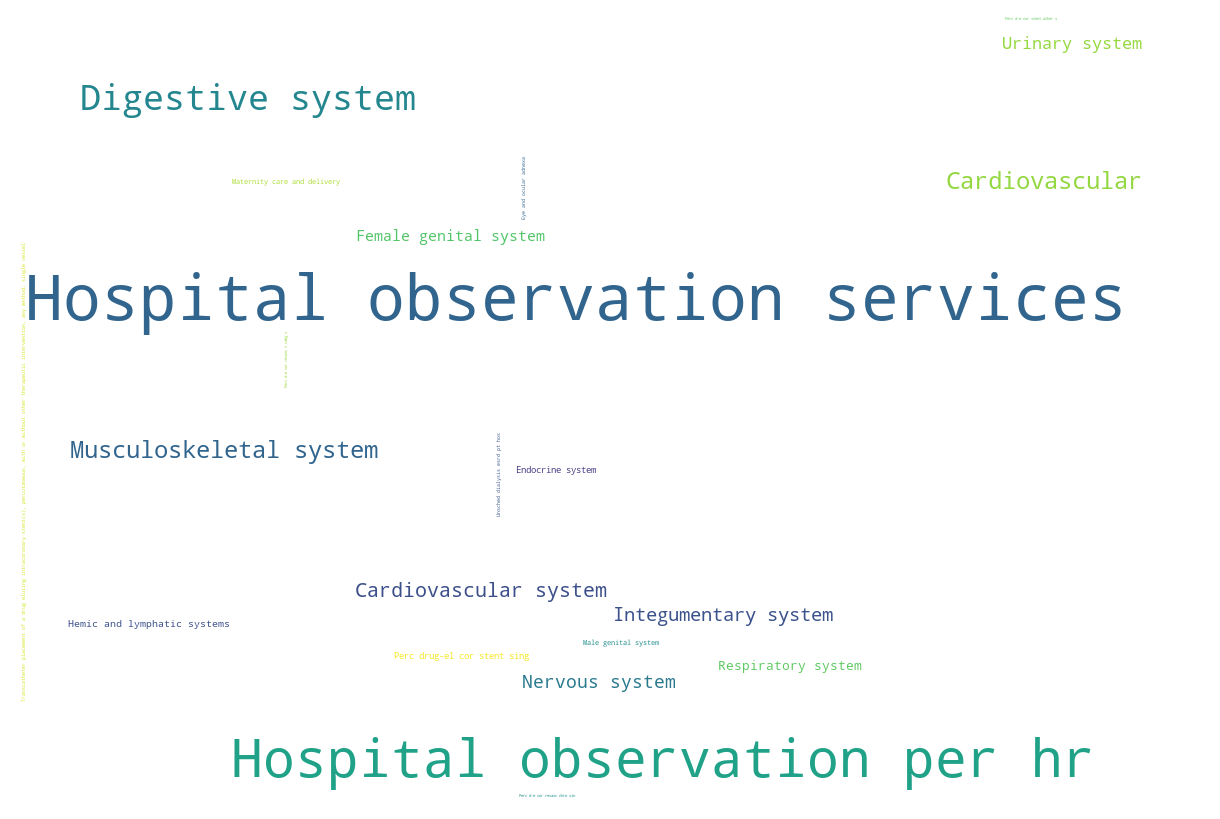

In [55]:
# Most frequent HCPCS services and procedures in MIMIC-IV Hosp module

hcpcsevents_file = os.path.join(base_directory, "raw_data","structured_data" ,"physionet.org" ,"files", "mimiciv", "3.1", "hosp","hcpcsevents.csv")
summary_directory = os.path.join(base_directory, 'processed_data', 'Summary')
d_hcpcsevents_file = os.path.join(base_directory, "raw_data","structured_data" ,"physionet.org", "files", "mimiciv", "3.1", "hosp", "d_hcpcs.csv")
data_dictionary_hcpcs = pd.read_csv(d_hcpcsevents_file,dtype=str)
# We need to have the same column names for code to perform the join operation
data_dictionary_hcpcs=data_dictionary_hcpcs.rename(columns={"code":"hcpcs_cd"})

generate_complete_summary(
    hcpcsevents_file, 
    data_dictionary_hcpcs,
    patient_id_col = "subject_id",
    code_cols= {"code": "hcpcs_cd"},
    cols_to_summarize=["subject_id","hcpcs_cd","chartdate"],
    code_desc_column = "short_description",
    summary_directory=summary_directory,
    batch_size=5000000
)

Total Rows in file: 859655
Most frequent values under each column:


,subject_id,subject_id_count,icd_code,icd_code_count,icd_version,icd_version_count
0,17295976,350,3893,14644,9,469209.0
1,19530208,199,02HV33Z,14353,10,390446.0
2,13475033,174,8938,10519,NaN,NaN
3,14873669,157,3897,10347,NaN,NaN
4,18553055,148,8856,9549,NaN,NaN


Processing chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.42it/s]


Most frequent codes and their corresponding patient counts


,icd_code,icd_version,counts,long_title
0,02HV33Z,10,11227,"Insertion of Infusion Device into Superior Vena Cava, Percutaneous Approach"
1,3893,9,10159,"Venous catheterization, not elsewhere classified"
2,8938,9,8807,Other nonoperative respiratory measurements
3,8856,9,7861,Coronary arteriography using two catheters
4,3897,9,7385,Central venous catheter placement with guidance


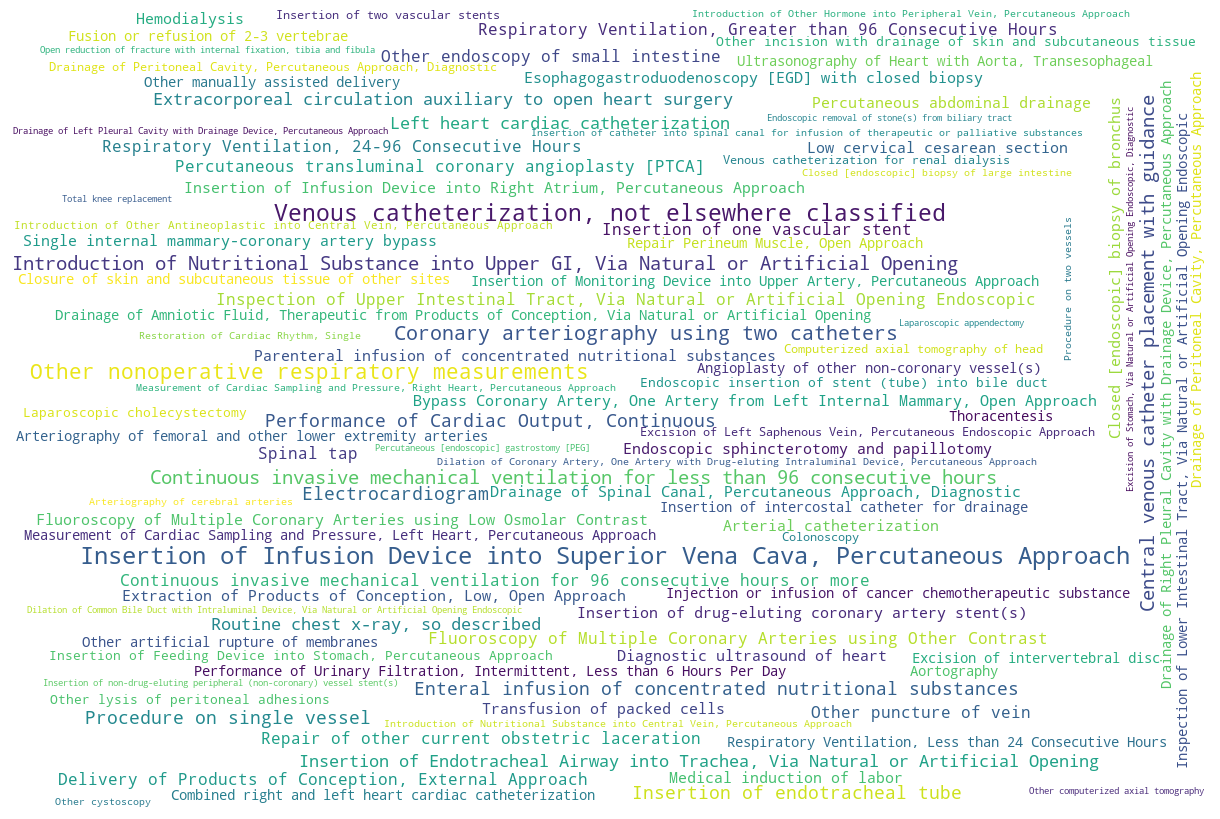

In [58]:
# Most frequent ICD procedures in MIMIC-IV Hosp module
procedures_icd_file = os.path.join(base_directory, "raw_data","structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp","procedures_icd.csv")
summary_directory = os.path.join(base_directory, 'processed_data', 'Summary')
d_icd_procedure_file = os.path.join(base_directory, "raw_data", "structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp", "d_icd_procedures.csv")
d_icd_procedure = pd.read_csv(d_icd_procedure_file,dtype=str)

generate_complete_summary(
    procedures_icd_file, 
    d_icd_procedure,
    patient_id_col = "subject_id",
    code_cols= {"code": "icd_code", "code_version":"icd_version"},
    cols_to_summarize=["subject_id","icd_code","icd_version"],
    summary_directory=summary_directory,
    code_desc_column="long_title",
    batch_size=5000000
)

,drug,ndc
0,Furosemide,51079007320
1,Ipratropium Bromide Neb,00487980125
2,Furosemide,51079007220
3,Potassium Chloride,00245004101
4,Sodium Chloride 0.9% Flush,0
...,...,...
20148201,diclofenac sodium,00115148361
20163079,Droperidol,00074118701
20180104,Flovent HFA,00173071820
20223809,Chromium Chloride,00409409301


Total Rows in file: 20292611
Most frequent values under each column:


,subject_id,subject_id_count,drug,drug_count,ndc,ndc_count
0,12468016,8269,Insulin,845166,0,2518625
1,10913302,5769,0.9% Sodium Chloride,728089,00338004904,384236
2,11389314,5552,Potassium Chloride,674552,63323026201,316791
3,10577647,5397,Sodium Chloride 0.9% Flush,673380,00338011704,292265
4,12294892,5302,Acetaminophen,586860,00409672924,227783


Processing chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:16<00:00,  3.22s/it]


Most frequent codes and their corresponding patient counts


,ndc,counts,drug
0,0,188786,Sodium Chloride 0.9% Flush
1,63323026201,112309,Heparin
2,00904224461,100746,Docusate Sodium
3,00338011704,97663,Lactated Ringers
4,00338004904,91143,Sodium Chloride 0.9%


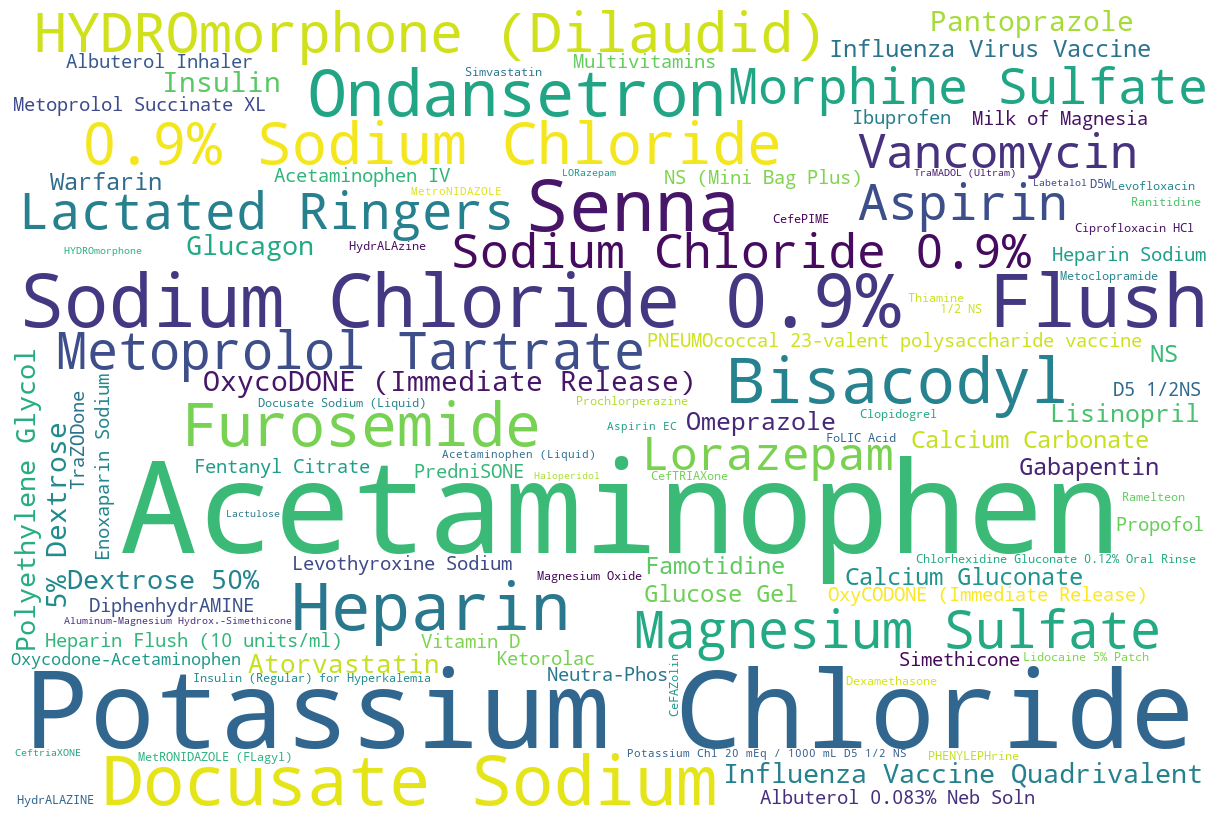

In [61]:
# Most frequently prescribed NDC medications in MIMIC-IV Hosp module

prescriptions_file = os.path.join(base_directory, "raw_data","structured_data", "physionet.org", "files", "mimiciv", "3.1", "hosp","prescriptions.csv")
summary_directory = os.path.join(base_directory, 'processed_data', 'Summary')
# We don't have a description file for NDC, so we create one based on the mapping provided inside the prescription file
d_prescription = pd.read_csv(prescriptions_file,dtype=str, usecols=['ndc','drug'])
d_prescription.drop_duplicates(subset=['ndc'],keep='first',inplace=True)
display(d_prescription)

generate_complete_summary(
    prescriptions_file, 
    d_prescription,
    patient_id_col = "subject_id",
    code_cols= {"code": "ndc"},
    cols_to_summarize=["subject_id","ndc","drug"],
    summary_directory=summary_directory,
    code_desc_column="drug",
    batch_size=5000000
)

,itemid,label,fluid,category
0,50801,Alveolar-arterial Gradient,Blood,Blood Gas
1,50802,Base Excess,Blood,Blood Gas
2,50803,"Calculated Bicarbonate, Whole Blood",Blood,Blood Gas
3,50804,Calculated Total CO2,Blood,Blood Gas
4,50805,Carboxyhemoglobin,Blood,Blood Gas


Total Rows in file: 158374764
Most frequent values under each column:


,subject_id,subject_id_count,itemid,itemid_count
0,12468016,44132,51221,4331615
1,13198542,38225,50912,4319091
2,10913302,36568,51265,4214048
3,12294892,36175,51006,4202807
4,18904293,33869,51222,4181121


Processing chunks: 100%|████████████████████████████████████████████████████████████████████████████████████████| 11/11 [01:25<00:00,  7.76s/it]


Most frequent codes and their corresponding patient counts


,itemid,counts,label,fluid,category
0,51221,298904,Hematocrit,Blood,Hematology
1,51265,298654,Platelet Count,Blood,Hematology
2,51222,298632,Hemoglobin,Blood,Hematology
3,51301,298581,White Blood Cells,Blood,Hematology
4,51279,298570,Red Blood Cells,Blood,Hematology


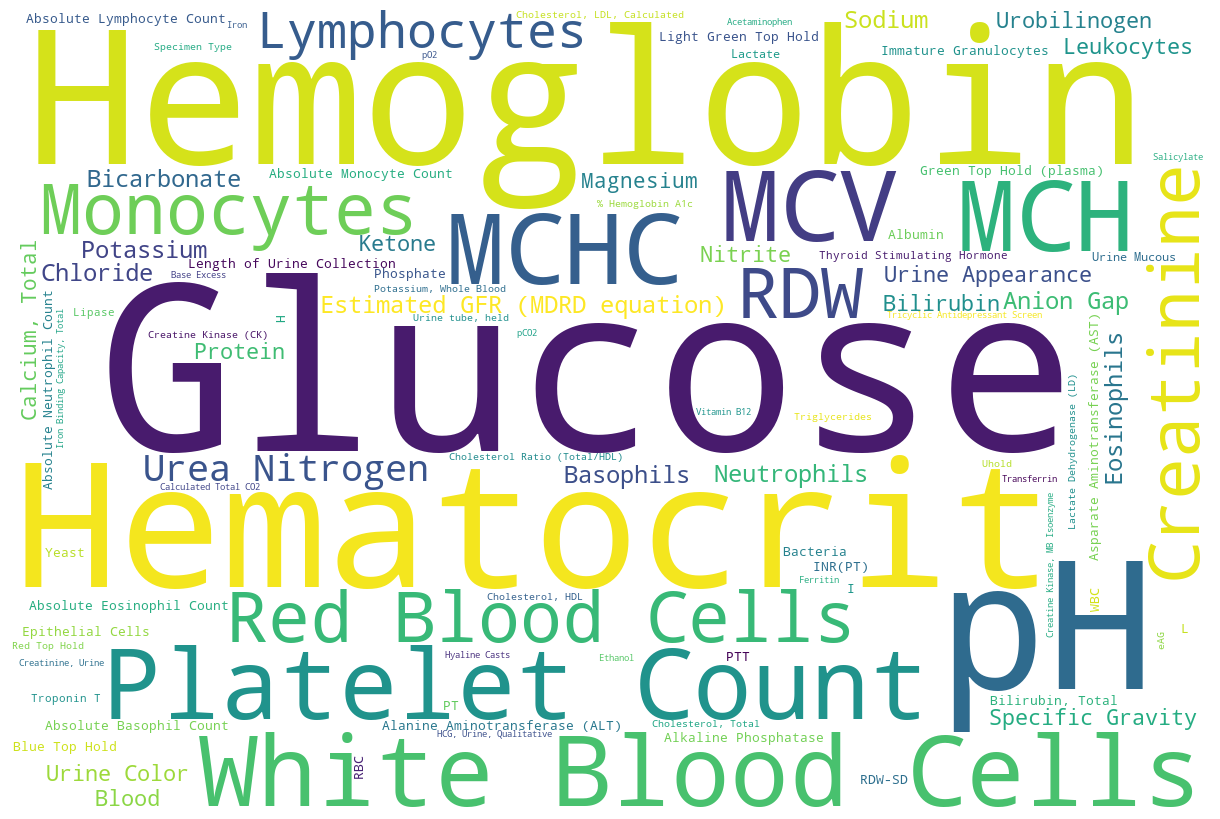

In [63]:
# Most frequently ordered lab tests in MIMIC-IV Hosp module

labitems_file = os.path.join(base_directory, "raw_data", "structured_data","physionet.org", "files", "mimiciv", "3.1", "hosp", "labevents.csv")
summary_directory = os.path.join(base_directory, 'processed_data', 'Summary')
d_labitems_file = os.path.join(base_directory, "raw_data", "structured_data","physionet.org", "files", "mimiciv", "3.1", "hosp", "d_labitems.csv")
d_labitems = pd.read_csv(d_labitems_file,dtype=str)
display(d_labitems.head())


generate_complete_summary(
    labitems_file, 
    d_labitems,
    patient_id_col = "subject_id",
    code_cols= {"code": "itemid"},
    cols_to_summarize=["subject_id","itemid"],
    summary_directory=summary_directory,
    code_desc_column="label",
    batch_size=15000000
)

At the end of the notebook, you will have the following summary files generated under your EHR_TUTORIAL_WORKSPACE/processed_data/Summary directory

`diagnoses_basic_summary.csv`  
`diagnoses_icd_basic_summary.csv`  
`diagnoses_icd_most_freq_items.csv`  
`diagnoses_icd_wordcloud.png`  
`diagnoses_patient_count.csv`  
`hcpcsevents_basic_summary.csv`  
`hcpcsevents_most_freq_items.csv`  
`hcpcsevents_wordcloud.png`  
`labevents_most_freq_items.csv`  
`labevents_wordcloud.png`  
`prescriptions_basic_summary.csv`  
`prescriptions_most_freq_items.csv`  
`prescriptions_wordcloud.png`  
`procedures_icd_basic_summary.csv`  
`procedures_icd_most_freq_items.csv`  
`procedures_icd_wordcloud.png`